In [1]:
from tjpcov.covariance_calculator import CovarianceCalculator
import numpy as np
from matplotlib import pyplot as plt
import healpy as hp
import sacc
import pymaster as nmt
import pyccl as ccl

import ipyparallel as ipp

In [2]:
zpz_lens = np.loadtxt('./data/FS2_30deg_3x2_6EP_noIA-nomag-nored-nowh_sharpcut_nofz_lens.txt', unpack=True)
zpz_sources = np.loadtxt('./data/FS2_30deg_3x2_6EP_noIA-nomag-nored-nowh_sharpcut_nofz_source.txt', unpack=True)

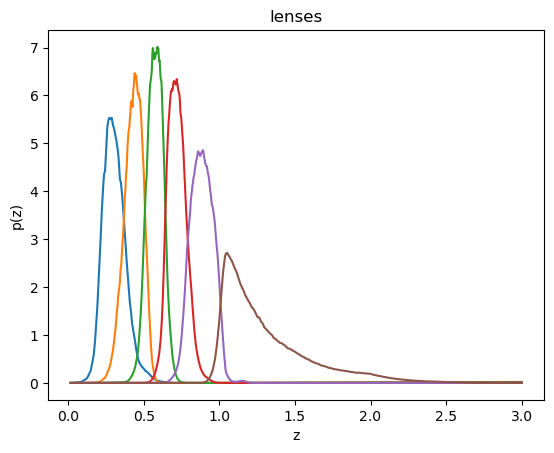

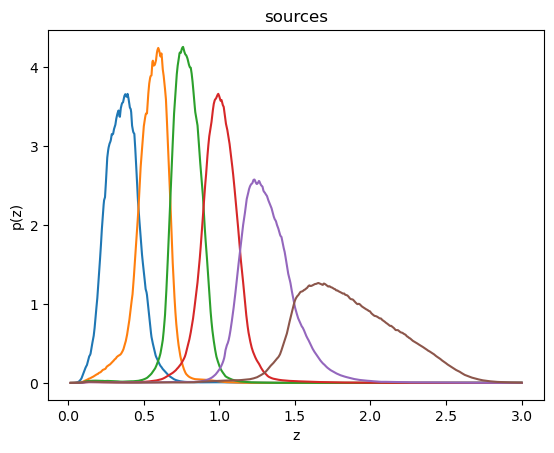

In [3]:
# Plot the redshift distributions

# lenses
for i in range(1, 7):
    plt.plot(zpz_lens[0], zpz_lens[i])
plt.xlabel('z')
plt.ylabel('p(z)')
plt.title('lenses')
plt.show()
plt.close()


# sources
for i in range(1, 7):
    plt.plot(zpz_sources[0], zpz_sources[i])
plt.xlabel('z')
plt.ylabel('p(z)')
plt.title('sources')
plt.show()
plt.close()

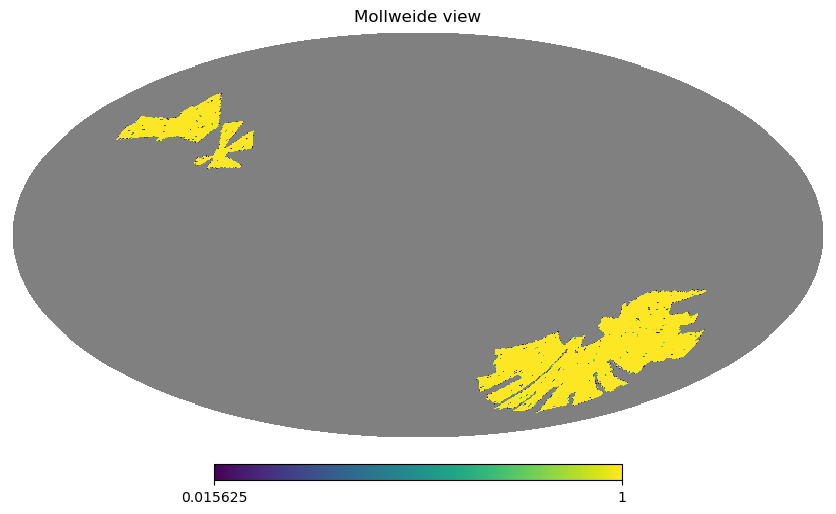

In [4]:
mask = hp.read_map('./data/rsd2024a-time-tagged-footprint-gal-12_DR1.fits')
mask[mask==0] = hp.UNSEEN
hp.mollview(mask)

In [5]:
# Instantiate NaMaster binning

ell_min =  10 
ell_max = 1024
ell_bins = 32 
# nmt_ell_binning: 'log'

# bpw_edges = np.arange(3*nside + 1)
bpw_edges = np.logspace(np.log10(ell_min), np.log10(ell_max), ell_bins, dtype=int)
bins = nmt.NmtBin.from_edges(ell_ini=bpw_edges[:-1], ell_end=bpw_edges[1:])
print('bpw_edges', bpw_edges)
print('ell_eff', bins.get_effective_ells())

ell_eff = bins.get_effective_ells()

bpw_edges [  10   11   13   15   18   21   24   28   33   38   44   51   60   69
   80   93  109  126  146  170  198  230  267  310  360  418  485  563
  654  759  881 1024]
ell_eff [ 10.   11.5  13.5  16.   19.   22.   25.5  30.   35.   40.5  47.   55.
  64.   74.   86.  100.5 117.  135.5 157.5 183.5 213.5 248.  288.  334.5
 388.5 451.  523.5 608.  706.  819.5 952. ]


In [6]:
# Nell coupled
fsky = np.mean(mask != hp.UNSEEN)

nl_cp_lens = 1 / 5.9806947133303705 * fsky
nl_cp_sources = 0.26 * 1.6885002375146223 * fsky

# Create the sacc file
s = sacc.Sacc()

# Add lenses
for i in range(1, 7):
    s.add_tracer('NZ', f'lens__{i}', quantity='galaxy_density', spin=0,
                  z=zpz_lens[0], nz=zpz_lens[i], metadata={'n_ell_coupled': nl_cp_lens})

# Add sources
for i in range(1, 7):
    s.add_tracer('NZ', f'sources__{i}', quantity='galaxy_shear', spin=2,
                 z=zpz_sources[0], nz=zpz_sources[i] , metadata={'n_ell_coupled': nl_cp_sources})

# Add data vector with 0's since it should not matter for the cov computation
tracers = list(s.tracers.keys())
for i, tr1 in enumerate(tracers):
    dt1 = '0' if 'lens' in tr1 else 'e'
    for tr2 in tracers[i:]:
        dt2 = '0' if 'lens' in tr2 else 'e'
        s.add_ell_cl(f'cl_{dt1}{dt2}', tr1, tr2, ell_eff, np.zeros_like(ell_eff))

print(tracers)
print('Data types:', s.get_data_types())
print('Number of combinations:', len(s.get_tracer_combinations()))
# # We need the bandpower window function
# wins = sacc.BandpowerWindow(cl_ij_cp_nmt['ell'],
#                             w['gc-gc'].get_bandpower_windows()[0, :, 0, :].T)
# s.add_ell_cl('cl_00', 'gc', 'gc', cl_ij_nmt['ell'], cl_ij_nmt['gc-gc'][0],
#              window=wins)

# # We need the bandpower window function
# wins = sacc.BandpowerWindow(cl_ij_cp_nmt['ell'],
#                             w['gc-wl'].get_bandpower_windows()[0, :, 0, :].T)
# s.add_ell_cl('cl_0e', 'gc', 'wl', cl_ij_nmt['ell'], cl_ij_nmt['gc-wl'][0],
#              window=wins)

# # We need the bandpower window function
# wins = sacc.BandpowerWindow(cl_ij_cp_nmt['ell'],
#                             w['wl-wl'].get_bandpower_windows()[0, :, 0, :].T)
# s.add_ell_cl('cl_ee', 'wl', 'wl', cl_ij_nmt['ell'], cl_ij_nmt['wl-wl'][0],
#              window=wins)

['lens__1', 'lens__2', 'lens__3', 'lens__4', 'lens__5', 'lens__6', 'sources__1', 'sources__2', 'sources__3', 'sources__4', 'sources__5', 'sources__6']
Data types: ['cl_00', 'cl_0e', 'cl_ee']
Number of combinations: 78


Computing independent covariance blocks
Computing the blocks for independent workspaces
('lens__1', 'lens__1') ('lens__1', 'lens__1')
Loading saved covariance ./cache/cov_lens__1_lens__1_lens__1_lens__1.npz
('lens__1', 'sources__1') ('lens__1', 'sources__1')
Loading saved covariance ./cache/cov_lens__1_sources__1_lens__1_sources__1.npz


/home/ardok/PD1-Oxford/codes/TJPCov/tjpcov/covariance_builder.py:913: UserWarning: Missing noise for some tracers in file. You will have to pass it with the cache
  warnings.warn(
/home/ardok/mambaforge/envs/EuclidTJPCov/lib/python3.12/site-packages/sacc/sacc.py:378: UserWarning: Empty index selected - maybe you should check the tracer order?
  warnings.warn("Empty index selected - maybe you "


('sources__1', 'sources__1') ('sources__1', 'sources__1')
Loading saved covariance ./cache/cov_sources__1_sources__1_sources__1_sources__1.npz
Computing the blocks for independent covariance workspaces
('lens__1', 'lens__1') ('lens__1', 'sources__1')
Loading saved covariance ./cache/cov_lens__1_lens__1_lens__1_sources__1.npz
('lens__1', 'lens__1') ('sources__1', 'sources__1')
Loading saved covariance ./cache/cov_lens__1_lens__1_sources__1_sources__1.npz
('lens__1', 'sources__1') ('lens__2', 'lens__2')
Loading saved covariance ./cache/cov_lens__1_sources__1_lens__2_lens__2.npz
('lens__1', 'sources__1') ('sources__1', 'sources__1')
Loading saved covariance ./cache/cov_lens__1_sources__1_sources__1_sources__1.npz
Computing the remaining blocks
('lens__1', 'lens__1') ('lens__1', 'lens__2')
Loading saved covariance ./cache/cov_lens__1_lens__1_lens__1_lens__2.npz
('lens__1', 'lens__1') ('lens__1', 'lens__3')
Loading saved covariance ./cache/cov_lens__1_lens__1_lens__1_lens__3.npz
('lens__1',

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



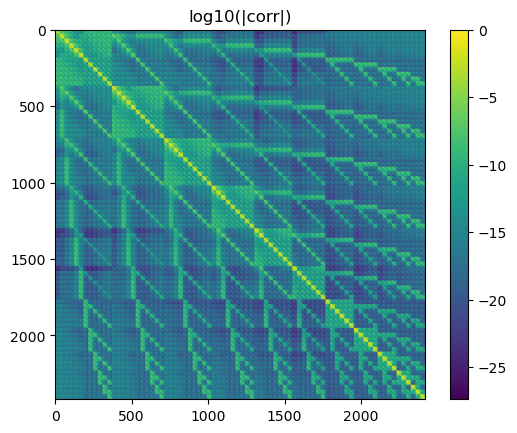

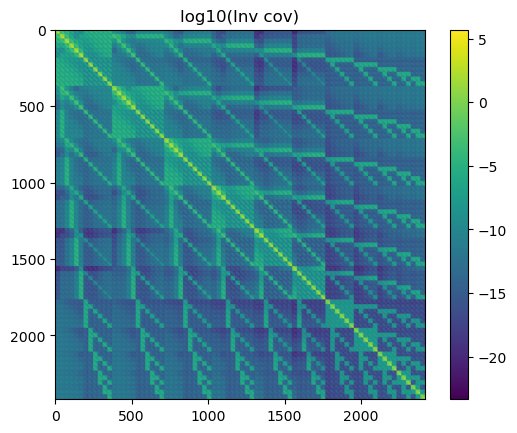

All eigenvalues > 0? True


In [7]:
# Create the config file
Omega_m = 0.319
Omega_b = 0.049
cosmo = {'Omega_c': Omega_m - Omega_b,
         'h': 0.67,
         'Omega_b': Omega_b,
         'n_s': 0.96,
         'A_s': 2.1e-9,
         # 'w': -1,
         # 'num_massive_neutrinos': 3,
         # 'nnu': 3.046,
         'm_nu': 0.06,
         # 'omega_k': 0.0,
         # 'tau': 0.0697186
        }


mask_names = {tr: 'EuclidMask' for tr in tracers}
mask_file = {tr: './data/rsd2024a-time-tagged-footprint-gal-12_DR1.fits' for tr in tracers}

# Ngal_lens = {f'Ngal_{tr}': 5.9806947133303705 for tr in tracers if 'lens' in tr}
# Ngal_sources = {f'Ngal_{tr}': 1.6885002375146223 for tr in tracers if 'sources' in tr}
# sigma_e = {f'sigma_e_{tr}': 0.26 for tr in tracers if 'sources' in tr}

config = {
    'parameters': cosmo,
    'tjpcov': 
          {'sacc_file': s,
           'cosmo': 'set',
           'cov_type': ['FourierGaussianNmt'],
           'IA': 0,
           'outdir': './cache',
           'mask_file': mask_file,
           'mask_names': mask_names,
           
           'bias_lens__1': 1.1440270903053593,
           'bias_lens__2': 1.209969007589984,
           'bias_lens__3': 1.3354449071064036,
           'bias_lens__4': 1.4219803534945,
           'bias_lens__5': 1.5275589801638865,
           'bias_lens__6': 1.9149796097338934,
          },

           "NaMaster": {
            "f": {
              "n_iter": 0,
              "lmax": bpw_edges[-1] - 1,
              "lmax_mask": bpw_edges[-1] - 1,  
            } },
           
            "cache": {
                'bins': bins
            }
         }

# config['tjpcov'].update(Ngal_lens)
# config['tjpcov'].update(Ngal_sources)
# config['tjpcov'].update(sigma_e)

# Compute the covariance
cc = CovarianceCalculator(config)
cov = cc.get_covariance()

diag = np.diag(cov)
corr = cov / np.sqrt(diag[:, None] * diag[None, :])
plt.imshow(np.log10(np.abs(corr)))
plt.colorbar()
plt.title('log10(|corr|)')
plt.show()
plt.close()


plt.imshow(np.log10(np.abs(np.linalg.inv(cov))))
plt.colorbar()
plt.title('log10(Inv cov)')
plt.show()
plt.close()

evl, evec = np.linalg.eigh(cov)
print('All eigenvalues > 0?', np.all(evl>0)) 